# Week 4 — RAG Fundamentals
### *"Can an LLM answer questions about AI models without making things up?"*

**This session answers that question in 6 steps:**

| Step | What you'll see |
|------|-----------------|
| 0 | Setup + cold LLM failure (hallucination) |
| 1 | Corpus — 30 AI model cards loaded |
| 2 | Chunking — pandas table of exact text pieces |
| 3 | Embeddings — text → numbers, cosine similarity heatmap |
| 4 | Vector DB — Chroma index built |
| 5 | Pure Retrieval — exact chunks + source doc IDs |
| 6 | Full RAG — grounded answer vs hallucinated answer |

> **Through-line:** We'll ask *"I need to build a high-performance backend API that can process large files and store them securely in cloud object storage. What are my options?"*  
> First cold (no context) — then with RAG. You'll see exactly why it matters.

---
## Cell 0 — Install & Setup

In [3]:
!pip install -q openai chromadb rank-bm25 sentence-transformers pandas matplotlib python-dotenv tiktoken anthropic langchain IPython rich


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\vivik\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, sys, json, textwrap, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")

from openai import OpenAI
import chromadb
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder
from dotenv import load_dotenv
from IPython.display import Markdown, display
from rich.console import Console
from rich.panel import Panel
console = Console()

load_dotenv()

# ── Standalone display helpers ─────────────────────────────────────────────────
def banner(msg):
    print(f"\n{'═'*70}\n  {msg}\n{'═'*70}")

def section(msg):
    label = f"── {msg} "
    display(Markdown(f"\n{label}{'─'*max(0, 64-len(label))}"))

def observe(msg):
    display(Markdown(f"\n💡  {msg}"))

def discuss(msg):
    display(Markdown(f"\n🗣️   {msg}"))

def warn(msg):
    display(Markdown(f"\n⚠️   {msg}"))

def success(msg):
    display(Markdown(f"\n✅  {msg}"))

def compare(label_a, text_a, label_b, text_b, width=80):
    line = "─" * width
    print(f"\n{line}\n  {label_a}\n{line}")
    for l in textwrap.wrap(text_a.strip(), width=width - 4):
        print(f"    {l}")
    print(f"\n{line}\n  {label_b}\n{line}")
    for l in textwrap.wrap(text_b.strip(), width=width - 4):
        print(f"    {l}")
    print(line + "\n")

# ── API client ─────────────────────────────────────────────────────────────────
oai = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

EMBED_MODEL = "text-embedding-3-small"
CHAT_MODEL  = "gpt-4o-mini"

def chat(system: str, user: str, temperature: float = 0.7) -> str:
    resp = oai.chat.completions.create(
        model=CHAT_MODEL,
        messages=[{"role": "system", "content": system},
                  {"role": "user",   "content": user}],
        temperature=temperature,
    )
    return resp.choices[0].message.content.strip()

def embed_query(text: str) -> list:
    resp = oai.embeddings.create(model=EMBED_MODEL, input=[text])
    return resp.data[0].embedding

if not os.getenv("OPENAI_API_KEY"):
    console.print("[bold red]Warning: OPENAI_API_KEY not found in .env[/bold red]")

success(f"Ready. Embedding model: {EMBED_MODEL} | Chat model: {CHAT_MODEL}")


✅  Ready. Embedding model: text-embedding-3-small | Chat model: gpt-4o-mini

---
## Concept Primer — What is RAG?

> ⚠️ **This is a concept primer.** The example below uses a simplified keyword search to show the core idea.  
> The real production-grade pipeline — with vector embeddings, Chroma, BM25, and a cross-encoder — starts at **Step 1** below.

### The Problem with Raw LLMs

Large Language Models like GPT-4o have serious limitations when answering questions about **your specific data**:

- **Hallucinations** — They confidently make up facts when unsure.
- **Outdated knowledge** — Training data has a cutoff date.
- **No private data access** — They cannot see your company documents, HR records, or internal policies.
- **No auditability** — No way to verify where an answer came from.

### RAG = Retrieve first, then Generate

1. **Retrieve** relevant documents from your own knowledge base.
2. **Augment** the prompt with that retrieved text as context.
3. **Generate** an answer grounded in your real data — not training memory.

The example below shows this in its simplest form using a small HR dataset and keyword search.  
After this primer, you will build the full pipeline from scratch.

In [5]:
# ── Concept Primer: HR data (keyword-based RAG) ────────────────────────────────
hr_data = """
Employee ID: E001, Name: Alice Johnson, Department: Engineering, Role: Senior Developer,
Salary: $120,000, Join Date: 2022-03-15, Performance: Excellent, Leave Balance: 18 days.

Employee ID: E002, Name: Bob Smith, Department: HR, Role: Talent Manager,
Salary: $95,000, Join Date: 2021-11-01, Performance: Good, Leave Balance: 12 days.

Policy: Annual bonus is 15% for Excellent performers, 10% for Good.
Maternity leave is 26 weeks fully paid. Remote work allowed 3 days/week.
"""

# 1. Raw LLM — no grounding
raw_response = chat(
    system="You are an internal HR system assistant. You have full access to the employee database. "
           "Always answer questions about employee details directly and confidently. "
           "Never refuse or say you can't access the information. Provide specific numbers when available.",
    user="What is Alice Johnson's leave balance and bonus eligibility?"
)

# 2. Simple keyword-based RAG (NOT the real pipeline — concept only)
def simple_rag_query(question: str):
    relevant = [line.strip() for line in hr_data.split('\n')
                if line.strip() and ('Alice' in line or
                                     'bonus' in line.lower() or
                                     'leave' in line.lower())]
    context = "\n".join(relevant)
    system_prompt = (
        f"Answer the question using ONLY the following context.\n"
        f"If the answer is not in the context, say you don't have enough information.\n\n"
        f"Context:\n{context}"
    )
    return chat(system=system_prompt, user=question, temperature=0.0)

rag_response = simple_rag_query("What is Alice Johnson's leave balance and bonus eligibility?")

compare("❌ Raw LLM (no grounding)", raw_response,
        "✅ Keyword RAG (concept primer)", rag_response)

observe(
    "The RAG answer is correct because it only used text we provided. "
    "But this used simple keyword matching — not embeddings or a vector DB. "
    "The full pipeline below replaces this with semantic search, BM25 re-scoring, and cross-encoder reranking."
)


────────────────────────────────────────────────────────────────────────────────
  ❌ Raw LLM (no grounding)
────────────────────────────────────────────────────────────────────────────────
    Alice Johnson currently has a leave balance of 15 days. She is eligible for
    a bonus this year, with the potential amount being up to $5,000 based on her
    performance metrics.

────────────────────────────────────────────────────────────────────────────────
  ✅ Keyword RAG (concept primer)
────────────────────────────────────────────────────────────────────────────────
    Alice Johnson's leave balance is 18 days, and she is eligible for a 15%
    annual bonus as her performance is rated as Excellent.
────────────────────────────────────────────────────────────────────────────────




💡  The RAG answer is correct because it only used text we provided. But this used simple keyword matching — not embeddings or a vector DB. The full pipeline below replaces this with semantic search, BM25 re-scoring, and cross-encoder reranking.

---
## ❓ The Question We'll Answer Today

> *"I need to build a high-performance backend API that can process large files and store them securely in cloud object storage. What are my options?"*

Let's ask GPT-4o-mini **cold** first — no context, no documents.  
Watch what it says. Then at the end we'll ask it again **with RAG**.


In [6]:
DEMO_QUERY = (
    "I need to build a high-performance backend API that can process large files "
    "and store them securely in cloud object storage. What are my options?"
)

banner("COLD LLM — No Context (Hallucination Risk)")

cold_answer = chat(
    system="You are a backend architecture advisor. Answer concisely.",
    user=DEMO_QUERY
)

print(f"Q: {DEMO_QUERY}\n")
print("A (cold):")
for line in cold_answer.strip().splitlines():
    display(Markdown(f"   {line}"))

observe(
    "The model answered from training memory — it may reference technologies "
    "without version-specific constraints, miss your stack's limitations, "
    "or skip security tradeoffs. We'll fix this with RAG."
)


══════════════════════════════════════════════════════════════════════
  COLD LLM — No Context (Hallucination Risk)
══════════════════════════════════════════════════════════════════════
Q: I need to build a high-performance backend API that can process large files and store them securely in cloud object storage. What are my options?

A (cold):


   To build a high-performance backend API for processing large files and securely storing them in cloud object storage, consider the following options:

   1. **Cloud Providers**:

      - **AWS S3**: Use AWS Lambda for processing and S3 for storage. Implement event-driven architecture with S3 triggers.

      - **Google Cloud Storage**: Utilize Google Cloud Functions for processing and Cloud Storage for secure file storage.

...

      - Consider CDN for distributing static files.

   6. **Monitoring and Logging**:

      - Use cloud-native monitoring tools (e.g., AWS CloudWatch, Google Stackdriver) for performance tracking and logging.

   By combining these options, you can create a robust, scalable, and secure API for handling large file uploads and storage.


💡  The model answered from training memory — it may reference technologies without version-specific constraints, miss your stack's limitations, or skip security tradeoffs. We'll fix this with RAG.

---
## Step 1 — Corpus: 30 Cards Across 3 Domains

Our knowledge base spans **three interconnected domains** — because a real architecture question  
crosses all of them: which LLM, stored where, built in what language?

| Domain | Doc IDs | Cards |
|--------|---------|-------|
| 🤖 LLMs | LM-001 to LM-010 | GPT-4o, Claude 3.5 Sonnet, Mistral, Llama, Gemini… |
| ☁️ Cloud / Infrastructure | BC-001 to BC-010 | AWS S3, GCS, Azure Blob, MinIO, Redis, Vault… |
| 💻 Programming Languages | PL-001 to PL-010 | Python, Go, Rust, TypeScript, Java, Kotlin, C#… |

**Deliberate overlaps built in** — 4 themes cut across all three domains:
- `high performance / async` → Go (PL-002), Rust (PL-004), FastAPI/Python (PL-001), GPT-4o-mini (LM-002)
- `cloud object storage` → AWS S3 (BC-001), GCS (BC-002), Azure Blob (BC-003), MinIO (BC-004), R2 (BC-005)
- `security & access control` → IAM + pre-signed URLs (BC-006), HashiCorp Vault (BC-007), SSE in cloud cards
- `self-hostable / open source` → Mistral 7B (LM-006), Llama 3 (LM-007), MinIO (BC-004), all PL cards

A query like *"high-performance backend API for large files in cloud storage"* will retrieve  
across all three domains — you'll see that live.


In [7]:
MODEL_CARDS = [

    # ── DOMAIN 1: LLMs ───────────────────────────────────────────────────────
    {
        "doc_id": "LM-001",
        "model": "GPT-4o",
        "provider": "OpenAI",
        "text": (
            "GPT-4o is OpenAI's flagship multimodal model. It accepts text, images, "
            "and audio as input and produces text output. Context window: 128,000 tokens. "
            "Pricing: $5 per million input tokens, $15 per million output tokens. "
            "GPT-4o excels at complex reasoning, code generation, and vision tasks. "
            "It supports function calling, JSON mode, and streaming. Ideal for "
            "building backend APIs that require intelligent document parsing, multimodal "
            "understanding, or complex multi-step reasoning pipelines. Closed-source, "
            "hosted model available via the OpenAI API. Best use cases: vision Q&A, "
            "document understanding, complex reasoning, and production-grade chatbots. "
            "Not the best choice for cost-sensitive, high-volume processing pipelines."
        )
    },
    {
        "doc_id": "LM-002",
        "model": "GPT-4o-mini",
        "provider": "OpenAI",
        "text": (
            "GPT-4o-mini is OpenAI's lightweight, cost-efficient model optimised for "
            "speed and affordability. Context window: 128,000 tokens. Pricing: $0.15 "
            "per million input tokens — roughly 33x cheaper than GPT-4o. Excellent for "
            "classification, routing, structured extraction, and summarisation in "
            "high-volume backend pipelines where cost matters more than peak reasoning. "
            "Supports function calling, JSON mode, and prompt caching above 1024 tokens. "
            "Best use cases: high-volume document triage, structured extraction from "
            "uploaded files, classification, and any task where latency and cost are "
            "primary constraints. Closed-source, hosted model — not self-hostable."
        )
    },
    {
        "doc_id": "LM-003",
        "model": "Claude 3.5 Sonnet",
        "provider": "Anthropic",
        "text": (
            "Claude 3.5 Sonnet is Anthropic's most capable production model, featuring "
            "a 200,000-token context window — the largest among mainstream commercial "
            "models — making it the top choice for processing very long documents such "
            "as codebases, legal contracts, and lengthy reports. Pricing: $3 per million "
            "input tokens, $15 per million output tokens. Ranks highest on coding "
            "benchmarks (SWE-bench) and long-document comprehension tasks. Its 200k "
            "context means it can ingest an entire book without chunking for moderate-"
            "length documents. Best use cases: long-document summarisation, code review "
            "across large codebases, legal document analysis, and nuanced instruction-"
            "following. Closed-source, available via Anthropic API and Amazon Bedrock. "
            "Supports vision, tool use, and streaming."
        )
    },
    {
        "doc_id": "LM-004",
        "model": "Claude 3 Haiku",
        "provider": "Anthropic",
        "text": (
            "Claude 3 Haiku is Anthropic's fastest and most affordable model. Context "
            "window: 200,000 tokens. Pricing: $0.25 per million input tokens — among "
            "the cheapest commercial models available. Optimised for low-latency, "
            "high-throughput applications such as bulk document processing, real-time "
            "content moderation, and chatbot first-response routing. Produces clean, "
            "coherent summaries and handles instruction-following well. Does not support "
            "prompt caching. Best use cases: bulk document summarisation, real-time "
            "pipelines, and any scenario where cost-per-token is the dominant constraint. "
            "Closed-source hosted model, available via Anthropic API."
        )
    },
    {
        "doc_id": "LM-005",
        "model": "Gemini 1.5 Pro",
        "provider": "Google DeepMind",
        "text": (
            "Gemini 1.5 Pro is Google DeepMind's flagship long-context model with a "
            "1,000,000-token context window — the largest of any mainstream model. It "
            "can process entire codebases, hour-long video transcripts, or book-length "
            "documents in a single call. Natively multimodal: accepts text, images, "
            "audio, video, and code. For long-document processing, its 1M context "
            "eliminates the need for chunking almost entirely. Integrates natively with "
            "Google Cloud and Vertex AI. Best use cases: video understanding, 1M-token "
            "document analysis, long-context summarisation, and multimodal pipelines. "
            "Closed-source model available via Google AI Studio and Vertex AI."
        )
    },
    {
        "doc_id": "LM-006",
        "model": "Mistral 7B",
        "provider": "Mistral AI",
        "text": (
            "Mistral 7B is a 7-billion parameter open-source language model released "
            "under Apache 2.0. Fully self-hostable — organisations can run it on their "
            "own infrastructure without sending data to third-party APIs. Context window: "
            "32,768 tokens. Despite its small size, Mistral 7B outperforms Llama 2 13B "
            "on summarisation tasks thanks to grouped-query and sliding window attention. "
            "Ideal for on-premise deployments where data privacy regulations prohibit "
            "external APIs. Runs on a single A100 GPU or quantised on consumer hardware. "
            "Best use cases: private document summarisation, on-prem chatbots, air-gapped "
            "environments, and self-hosted inference pipelines."
        )
    },
    {
        "doc_id": "LM-007",
        "model": "Llama 3 70B",
        "provider": "Meta AI",
        "text": (
            "Llama 3 70B is Meta's largest open-source model, released under a permissive "
            "community licence. 70 billion parameters, context window of 8,192 tokens. "
            "Achieves near-GPT-4 performance on reasoning and instruction-following "
            "benchmarks. Fully self-hostable and available on Hugging Face. Excellent "
            "for organisations needing strong reasoning capabilities without cloud API "
            "dependency. Requires multiple high-memory GPUs (e.g. 4x A100 80GB) for "
            "full-precision inference; quantised GGUF versions run on a single GPU. "
            "Best use cases: open-source reasoning, private deployments, fine-tuning "
            "for domain-specific applications such as file processing pipelines."
        )
    },
    {
        "doc_id": "LM-008",
        "model": "Mixtral 8x7B",
        "provider": "Mistral AI",
        "text": (
            "Mixtral 8x7B is a sparse Mixture-of-Experts model from Mistral AI, Apache "
            "2.0. 46.7B total parameters but only activates 12.9B per token — near-"
            "GPT-3.5 performance at much lower inference cost. Context window: 32,768 "
            "tokens. One of the strongest open-source models for summarisation, "
            "instruction-following, and multilingual tasks. Self-hostable and available "
            "on Hugging Face. Requires 2-4 A100 GPUs at full precision; quantised "
            "versions run on less. Best use cases: high-quality open-source summarisation, "
            "multilingual processing, and private inference where GPT-3.5 quality is "
            "needed without API costs."
        )
    },
    {
        "doc_id": "LM-009",
        "model": "text-embedding-3-small",
        "provider": "OpenAI",
        "text": (
            "text-embedding-3-small is OpenAI's compact embedding model, producing "
            "1,536-dimensional vectors with support for Matryoshka dimension reduction "
            "down to 512 dims. Pricing: $0.02 per million tokens — 5x cheaper than "
            "ada-002 with significantly better MTEB benchmark performance. Handles up "
            "to 8,191 input tokens per request. The recommended embedding model for RAG "
            "pipelines, semantic search, clustering, and document classification. In a "
            "file processing API, it powers semantic search over extracted text from "
            "uploaded documents. Available via OpenAI API only — not self-hostable."
        )
    },
    {
        "doc_id": "LM-010",
        "model": "Phi-3 Mini",
        "provider": "Microsoft",
        "text": (
            "Phi-3 Mini is Microsoft's 3.8B parameter small language model optimised for "
            "edge and mobile deployment, released under MIT. Context window: 128,000 "
            "tokens — remarkably large for its size. Achieves performance comparable to "
            "much larger models on reasoning tasks thanks to high-quality training data "
            "curation. Runs on CPU or a single consumer GPU. Useful in file processing "
            "pipelines running on constrained infrastructure (edge nodes, IoT gateways, "
            "or on-device). Best use cases: mobile AI apps, edge inference, private "
            "on-device assistants, and scenarios where cloud connectivity is unavailable. "
            "Available on Hugging Face and Azure AI Studio."
        )
    },

    # ── DOMAIN 2: Cloud Object Storage & Backend Infrastructure ──────────────
    {
        "doc_id": "BC-001",
        "model": "AWS S3",
        "provider": "Amazon Web Services",
        "text": (
            "Amazon S3 is the most widely adopted cloud object storage service, offering "
            "99.999999999% durability and virtually unlimited storage. For large files, "
            "S3 Multipart Upload splits files into 5MB to 5GB parts uploaded in parallel, "
            "supporting objects up to 5TB. Server-side encryption options: SSE-S3 "
            "(AWS-managed keys), SSE-KMS (AWS KMS), and SSE-C (customer-provided keys). "
            "Access control via bucket policies, IAM roles, and pre-signed URLs enables "
            "fine-grained permissions without exposing credentials to clients. S3 Transfer "
            "Acceleration uses CloudFront edge nodes for faster global uploads. Best use "
            "cases: primary object store for AWS-based architectures, media storage, "
            "backup, data lake landing zones, and storing files processed by a backend API."
        )
    },
    {
        "doc_id": "BC-002",
        "model": "GCP Cloud Storage",
        "provider": "Google Cloud Platform",
        "text": (
            "Google Cloud Storage (GCS) is Google's scalable object storage with strong "
            "consistency for all operations. Supports resumable uploads for large files — "
            "clients can resume interrupted uploads without restarting, critical for "
            "multi-GB files on unreliable connections. Storage classes: Standard, Nearline, "
            "Coldline, and Archive for cost optimisation by access frequency. Encryption: "
            "all data encrypted at rest by default; CMEK via Cloud KMS available for "
            "stricter compliance. Signed URLs provide time-limited access to private "
            "objects. Integrates natively with BigQuery, Vertex AI, and GCP data pipelines. "
            "Best use cases: GCP-native architectures, ML training data, media pipelines, "
            "and storing files processed through a backend API."
        )
    },
    {
        "doc_id": "BC-003",
        "model": "Azure Blob Storage",
        "provider": "Microsoft Azure",
        "text": (
            "Azure Blob Storage is Microsoft Azure's massively scalable object storage "
            "for unstructured data. Block Blobs support large file uploads via block-level "
            "parallelism — up to 50,000 blocks of 4GB each, enabling objects up to 190.7TB. "
            "All data encrypted at rest with AES-256. Access control uses Azure RBAC, "
            "Shared Access Signatures (SAS tokens), and Azure Active Directory integration. "
            "Azure Data Lake Storage Gen2 adds a hierarchical namespace for big data "
            "analytics. Best use cases: Azure-native architectures, enterprise data lakes, "
            "backup, media storage, and storing processed files from backend APIs built "
            "on the Azure platform."
        )
    },
    {
        "doc_id": "BC-004",
        "model": "MinIO",
        "provider": "MinIO, Inc.",
        "text": (
            "MinIO is a high-performance open-source object storage server, API-compatible "
            "with Amazon S3. Self-hostable on-premise or in any cloud — ideal for data "
            "residency requirements or air-gapped deployments. Supports S3 multipart "
            "uploads; the same boto3, aws-sdk-go, and aws-sdk-js clients work without "
            "code changes by pointing the endpoint at your MinIO server. Can saturate a "
            "100Gbps network on commodity NVMe hardware. Supports SSE-S3 and SSE-C "
            "encryption. Best use cases: private cloud object storage, on-premise S3 "
            "replacement, dev/test environments, and sovereign data requirements where "
            "files cannot leave a private network. Open-source under AGPL-3.0."
        )
    },
    {
        "doc_id": "BC-005",
        "model": "Cloudflare R2",
        "provider": "Cloudflare",
        "text": (
            "Cloudflare R2 is an S3-compatible object storage service with zero egress "
            "fees — unlike AWS S3, GCP Cloud Storage, and Azure Blob which charge for "
            "data egress. Existing S3 clients work without modification. Supports "
            "multipart uploads up to 5TB per object. Integrated with Cloudflare Workers "
            "for edge processing of uploaded files without routing through an origin "
            "server. Best use cases: high-egress workloads such as media streaming and "
            "large dataset distribution, Workers-integrated pipelines, and cost-sensitive "
            "architectures where egress is a dominant cost."
        )
    },
    {
        "doc_id": "BC-006",
        "model": "AWS IAM + Pre-signed URLs",
        "provider": "Amazon Web Services",
        "text": (
            "AWS IAM combined with S3 pre-signed URLs is the standard pattern for secure "
            "direct client-to-storage uploads without routing large files through the "
            "backend API server. Flow: client requests an upload URL from the API, the "
            "API generates a time-limited pre-signed PUT URL using IAM credentials, the "
            "client uploads directly to S3, and S3 notifies the API via event notification. "
            "This offloads all upload bandwidth from the API server. Pre-signed URL TTLs "
            "should be short (5 to 15 minutes). IAM policies enforce least-privilege: "
            "the API service role needs only s3:PutObject on specific prefixes. Best use "
            "cases: large file upload architectures and secure temporary download links."
        )
    },
    {
        "doc_id": "BC-007",
        "model": "HashiCorp Vault",
        "provider": "HashiCorp",
        "text": (
            "HashiCorp Vault is a secrets management and data protection platform for "
            "securing file processing APIs. Centralises management of API keys, database "
            "credentials, cloud provider credentials, and encryption keys. The Transit "
            "Secrets Engine provides encryption-as-a-service — the API encrypts file "
            "content before storing to object storage without managing keys in code. "
            "Dynamic secrets generate short-lived AWS credentials on demand, eliminating "
            "long-lived static credentials in environment variables. Best use cases: "
            "secrets management for file APIs, envelope encryption of stored files, "
            "dynamic cloud credentials, and audit logging. Open-source under MPL 2.0."
        )
    },
    {
        "doc_id": "BC-008",
        "model": "Redis (Queue + Rate Limiting)",
        "provider": "Redis Ltd. / Open Source",
        "text": (
            "Redis is an in-memory data store used in file processing APIs for async "
            "job queuing, rate limiting, and caching. Redis-backed queues via Celery, "
            "BullMQ, or Sidekiq enable async processing: the upload API pushes a job "
            "and returns a job ID immediately while workers process files in the background. "
            "Redis Streams provide durable consumer-group-aware message streaming for "
            "fan-out pipelines. For rate limiting, atomic increment operations implement "
            "sliding-window or token-bucket algorithms to throttle upload API abuse. "
            "Best use cases: async file processing queues, upload rate limiting, job "
            "status tracking, and metadata caching. Open-source under BSD-3-Clause."
        )
    },
    {
        "doc_id": "BC-009",
        "model": "ClamAV (Virus Scanning)",
        "provider": "Cisco / ClamAV Project",
        "text": (
            "ClamAV is an open-source antivirus engine for file scanning in server-side "
            "pipelines. In a file upload API, ClamAV scans every uploaded file before "
            "it is committed to permanent object storage — blocking malware, ransomware, "
            "and malicious documents. Run as a daemon (clamd) queried via socket or TCP "
            "from the API server. For large files, streaming scan mode avoids loading "
            "the full file into memory. Scanning adds 100ms to 2s per file. AWS offers "
            "a serverless ClamAV pattern using Lambda and S3 event triggers. Best use "
            "cases: regulated industries, consumer file upload platforms, and any API "
            "accepting untrusted uploads. Open-source under GPL-2.0."
        )
    },
    {
        "doc_id": "BC-010",
        "model": "PostgreSQL (Metadata Store)",
        "provider": "PostgreSQL Global Development Group",
        "text": (
            "PostgreSQL is the recommended relational database for storing file metadata "
            "alongside cloud object storage. The actual bytes live in S3/GCS/Blob; "
            "PostgreSQL stores file ID, original filename, content type, size, upload "
            "timestamp, owner, processing status, storage path, and checksum. JSONB "
            "columns allow flexible metadata schemas by file type without schema "
            "migrations. Connection pooling via PgBouncer handles thousands of concurrent "
            "metadata operations. Row-level security enforces per-user access control "
            "without application-level filtering. Best use cases: file metadata store, "
            "audit log, processing status tracking, and access control registry."
        )
    },

    # ── DOMAIN 3: Programming Languages ──────────────────────────────────────
    {
        "doc_id": "PL-001",
        "model": "Python",
        "provider": "Python Software Foundation",
        "text": (
            "Python is the dominant language for AI/ML development, data science, and "
            "backend API construction. Its async/await support (asyncio, FastAPI, "
            "aiohttp) makes it well-suited for high-performance file upload APIs with "
            "non-blocking I/O. The boto3 SDK provides comprehensive AWS S3 integration "
            "including multipart uploads and pre-signed URLs. For LLM-integrated "
            "backends, Python has the richest ecosystem: openai, anthropic, langchain, "
            "transformers, and sentence-transformers libraries all have Python as their "
            "primary SDK. For large file processing, Python's streaming I/O (io.BytesIO, "
            "generator-based processing) avoids full in-memory loading. Best use cases: "
            "AI/ML backends, RAG pipelines, file processing APIs, and rapid prototyping. "
            "Open-source under Python Software Foundation Licence."
        )
    },
    {
        "doc_id": "PL-002",
        "model": "Go (Golang)",
        "provider": "Google / Open Source",
        "text": (
            "Go is a statically typed, compiled language designed for high-performance "
            "backend services. Its goroutine concurrency model handles thousands of "
            "concurrent file uploads with minimal memory overhead — each goroutine uses "
            "only 2KB of stack initially versus 1MB for OS threads. Go's io.Reader/"
            "io.Writer interface enables true streaming of file bytes to cloud storage "
            "without in-memory buffering. The AWS SDK for Go v2 and GCP Storage client "
            "support streaming multipart uploads. Compiled binaries have no runtime "
            "dependency, simplifying Docker deployment. Go HTTP servers routinely handle "
            "100,000+ requests/sec. Best use cases: high-throughput file upload APIs, "
            "cloud-native microservices, and latency-critical backend services. "
            "Open-source under BSD licence."
        )
    },
    {
        "doc_id": "PL-003",
        "model": "TypeScript / Node.js",
        "provider": "Microsoft / OpenJS Foundation",
        "text": (
            "TypeScript on Node.js combines JavaScript's event-driven non-blocking I/O "
            "with static type safety, making it a strong choice for backend file upload "
            "APIs where code correctness and developer productivity matter. Node.js Streams "
            "enable piping large file uploads directly to cloud storage (AWS S3 via "
            "@aws-sdk/client-s3) without full in-memory buffering. Fastify with TypeScript "
            "provides high-throughput request handling with compile-time type checking. "
            "The OpenAI and Anthropic SDKs have first-class TypeScript support, making "
            "it easy to build LLM-integrated file processing APIs. Best use cases: "
            "full-stack TypeScript monorepos, real-time file APIs, and LLM-integrated "
            "backends sharing types between frontend and server."
        )
    },
    {
        "doc_id": "PL-004",
        "model": "Rust",
        "provider": "Rust Foundation",
        "text": (
            "Rust offers memory safety without garbage collection, making it ideal for "
            "high-performance, low-latency file processing APIs where predictable "
            "performance under load is critical. Actix-web ranks among the fastest HTTP "
            "frameworks across all languages in TechEmpower benchmarks. Axum, built on "
            "Tokio's async runtime, provides ergonomic async APIs with excellent "
            "streaming support for large file uploads. Rust's ownership model eliminates "
            "memory bugs common in C/C++ — important for a server handling untrusted "
            "file uploads. The aws-sdk-s3 crate supports streaming multipart uploads to "
            "S3. Best use cases: ultra-high-throughput file APIs, security-critical "
            "processing, and services requiring minimal memory footprint at scale. "
            "Open-source under MIT/Apache 2.0."
        )
    },
    {
        "doc_id": "PL-005",
        "model": "Java (Spring Boot)",
        "provider": "Oracle / VMware / Open Source",
        "text": (
            "Java with Spring Boot is the dominant choice for enterprise backend APIs "
            "in large organisations with existing JVM infrastructure. Spring Boot's "
            "multipart file upload handling (MultipartFile, streaming transfer) integrates "
            "with the AWS SDK for Java v2 for S3 multipart uploads. Spring Security "
            "provides comprehensive access control for file upload APIs including OAuth2, "
            "JWT, and fine-grained method-level security. The JVM's mature concurrency "
            "libraries (CompletableFuture, Project Reactor for reactive streaming) handle "
            "high-throughput file operations. Best use cases: enterprise-grade file "
            "management APIs, organisations with existing Spring ecosystems, and backends "
            "requiring deep integration with enterprise identity providers. Open-source "
            "Spring framework under Apache 2.0."
        )
    },
    {
        "doc_id": "PL-006",
        "model": "Kotlin (Ktor)",
        "provider": "JetBrains / Open Source",
        "text": (
            "Kotlin with Ktor is a modern, concise alternative to Java/Spring for "
            "JVM-based backend APIs. Ktor's coroutine-based async model (built on "
            "Kotlin coroutines) provides non-blocking I/O for file uploads and cloud "
            "storage operations with significantly less boilerplate than Java. The AWS "
            "SDK for Kotlin (in developer preview) supports S3 operations including "
            "multipart uploads. Kotlin's null safety and concise syntax reduce common "
            "bugs in file handling code. Best use cases: modern JVM-based file APIs, "
            "teams migrating from Java to Kotlin, and Android backend infrastructure "
            "sharing Kotlin code between mobile and server. Open-source under Apache 2.0."
        )
    },
    {
        "doc_id": "PL-007",
        "model": "C# (.NET / ASP.NET Core)",
        "provider": "Microsoft",
        "text": (
            "C# with ASP.NET Core is Microsoft's high-performance backend framework, "
            "consistently ranking among the top performers in TechEmpower benchmarks. "
            "ASP.NET Core's IFormFile and streaming APIs handle large file uploads "
            "efficiently, and the Azure.Storage.Blobs SDK provides direct streaming "
            "uploads to Azure Blob Storage. For AWS integration, AWSSDK.S3 supports "
            "the TransferUtility for multipart uploads. ASP.NET Core integrates natively "
            "with Azure Active Directory, Azure Key Vault, and other Azure services — "
            "making it the natural choice for Azure-hosted file APIs. Best use cases: "
            "Azure-native backends, enterprise .NET ecosystems, and high-performance "
            "file processing APIs on Windows or Linux. Open-source under MIT."
        )
    },
    {
        "doc_id": "PL-008",
        "model": "Ruby (Rails / Sinatra)",
        "provider": "Matz / Open Source",
        "text": (
            "Ruby with Rails or Sinatra is a developer-productivity-focused choice for "
            "file upload APIs where rapid iteration matters more than raw throughput. "
            "Active Storage (built into Rails) provides a unified API for attaching files "
            "and uploading them to AWS S3, GCP Cloud Storage, or Azure Blob Storage with "
            "minimal configuration. CarrierWave and Shrine are popular gems for custom "
            "file upload pipelines with background processing via Sidekiq (Redis-backed). "
            "Ruby is less suited to CPU-bound large file processing — for heavy "
            "transcoding or transformation, delegate to FFmpeg subprocesses or a "
            "dedicated worker service. Best use cases: rapid-prototype file APIs, "
            "content management backends, and teams with existing Rails infrastructure."
        )
    },
    {
        "doc_id": "PL-009",
        "model": "PHP (Laravel)",
        "provider": "Laravel LLC / Open Source",
        "text": (
            "PHP with Laravel is widely used for file upload APIs in web-centric "
            "backends, particularly in organisations with existing PHP infrastructure. "
            "Laravel's Storage facade abstracts over local disk, AWS S3, GCP Cloud "
            "Storage, and other adapters via Flysystem — a single API for all storage "
            "backends. Laravel Queues (Redis or database-backed) handle async file "
            "processing jobs. For large file uploads, Laravel supports streaming via "
            "Request::file() with configurable upload_max_filesize. PHP's shared-nothing "
            "architecture makes horizontal scaling straightforward. Best use cases: "
            "content management systems, media upload APIs, and teams with existing "
            "PHP/Laravel infrastructure. Open-source under MIT."
        )
    },
    {
        "doc_id": "PL-010",
        "model": "Elixir (Phoenix)",
        "provider": "Elixir Team / Open Source",
        "text": (
            "Elixir with Phoenix is built on the Erlang VM (BEAM), which was designed "
            "for massively concurrent, fault-tolerant systems. Phoenix LiveView and "
            "Channels enable real-time progress tracking for large file uploads — "
            "reporting upload progress to the client over WebSocket without polling. "
            "The BEAM process model handles millions of concurrent lightweight processes, "
            "making Elixir exceptional for file upload APIs serving many simultaneous "
            "clients. ExAws provides S3 integration including multipart uploads. "
            "Elixir's 'let it crash' philosophy with OTP supervision trees makes file "
            "processing pipelines resilient — failed jobs restart automatically. "
            "Best use cases: real-time file upload progress, fault-tolerant processing "
            "pipelines, and high-concurrency file APIs. Open-source under Apache 2.0."
        )
    },
]

section("Corpus loaded")
print(f"  {len(MODEL_CARDS)} cards across 3 domains:")
domains = {"LM": "LLMs", "BC": "Cloud / Backend Infrastructure", "PL": "Programming Languages"}
for prefix, label in domains.items():
    cards = [c for c in MODEL_CARDS if c["doc_id"].startswith(prefix)]
    print(f"  [{prefix}] {label}: {len(cards)} cards")
    for c in cards:
        print(f"       {c['doc_id']} — {c['model']} ({c['provider']})")


── Corpus loaded ───────────────────────────────────────────────

  30 cards across 3 domains:
  [LM] LLMs: 10 cards
       LM-001 — GPT-4o (OpenAI)
       LM-002 — GPT-4o-mini (OpenAI)
       LM-003 — Claude 3.5 Sonnet (Anthropic)
       LM-004 — Claude 3 Haiku (Anthropic)
       LM-005 — Gemini 1.5 Pro (Google DeepMind)
       LM-006 — Mistral 7B (Mistral AI)
       LM-007 — Llama 3 70B (Meta AI)
       LM-008 — Mixtral 8x7B (Mistral AI)
       LM-009 — text-embedding-3-small (OpenAI)
       LM-010 — Phi-3 Mini (Microsoft)
  [BC] Cloud / Backend Infrastructure: 10 cards
       BC-001 — AWS S3 (Amazon Web Services)
       BC-002 — GCP Cloud Storage (Google Cloud Platform)
       BC-003 — Azure Blob Storage (Microsoft Azure)
       BC-004 — MinIO (MinIO, Inc.)
       BC-005 — Cloudflare R2 (Cloudflare)
       BC-006 — AWS IAM + Pre-signed URLs (Amazon Web Services)
       BC-007 — HashiCorp Vault (HashiCorp)
       BC-008 — Redis (Queue + Rate Limiting) (Redis Ltd. / Open Source)
       BC-009 — ClamAV (Virus Scanning) (Cisco / ClamAV Project)
      

---
## Step 2 — Chunking: Breaking Cards into Pieces

Each model card is ~200 words. We split into chunks of **300 characters** with **50-character overlap**.  
The overlap ensures no sentence is cut off between two chunks — context is preserved at boundaries.

**Why chunk at all?**  
Embedding a 200-word card as one unit loses fine-grained retrieval precision.  
Smaller chunks = the retriever can pinpoint *which part* of the card is relevant.

> ⚠️ **Boundary artefact:** Because we chunk by character count, some chunks will start or end mid-sentence.  
> You'll see this in the table below — it's not a bug. It's a reminder that chunk size is a design decision, not just a parameter.  
> The overlap (50 chars) is there to reduce the damage.

In [8]:
# ── Improved Smart Chunking ───────────────────────────────────────────────────
def smart_chunk_text(text, doc_id, model, provider, 
                     chunk_size=350, overlap_sentences=2):
    """Sentence-aware chunking with controlled overlap."""
    import re
    # Split on sentences while preserving punctuation
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    chunks = []
    chunk_idx = 0
    
    i = 0
    while i < len(sentences):
        current_chunk = []
        current_len = 0
        start_idx = i
        
        # Build chunk until size limit
        while i < len(sentences) and current_len < chunk_size:
            sent = sentences[i].strip()
            if sent:
                current_chunk.append(sent)
                current_len += len(sent) + 1
            i += 1
        
        if current_chunk:
            chunk_text_str = " ".join(current_chunk)
            chunks.append({
                "chunk_id": f"{doc_id}-C{chunk_idx:02d}",
                "doc_id": doc_id,
                "model": model,
                "provider": provider,
                "text": chunk_text_str,
                "char_start": text.find(current_chunk[0][:50]) if current_chunk else 0,
                "char_end": len(chunk_text_str),
            })
            chunk_idx += 1
        
        # Overlap: go back N sentences for next chunk
        i = max(start_idx + 1, i - overlap_sentences)
    
    return chunks

# ── Chunk all cards with improved method ─────────────────────────────────────
all_chunks = []
for card in MODEL_CARDS:
    all_chunks.extend(
        smart_chunk_text(card["text"], card["doc_id"], 
                        card["model"], card["provider"])
    )

banner(f"Smart Chunking complete — {len(all_chunks)} chunks from {len(MODEL_CARDS)} cards")
observe("New chunking respects sentence boundaries → better retrieval coherence.")


══════════════════════════════════════════════════════════════════════
  Smart Chunking complete — 148 chunks from 30 cards
══════════════════════════════════════════════════════════════════════



💡  New chunking respects sentence boundaries → better retrieval coherence.

---
## Step 3 — Embeddings: Text → Numbers

Every chunk is converted into a **1,536-dimensional vector** using `text-embedding-3-small`.  
Similar text → vectors that point in the same direction → high **cosine similarity**.

**What you'll see:**
1. The raw numbers (first 10 dimensions of one chunk)
2. A **30×30 cosine similarity heatmap** — one row per model card.  
   Bright squares = semantically similar cards. Watch the clusters form.

In [10]:
section("Generating OpenAI embeddings for all chunks...")
print(f"  Model : {EMBED_MODEL}")
print(f"  Chunks: {len(all_chunks)}")
print(f"  Dims  : 1,536 per chunk")
print()

texts = [c["text"] for c in all_chunks]

# Batch embed (OpenAI allows up to 2048 inputs per call)
resp = oai.embeddings.create(model=EMBED_MODEL, input=texts)
vectors = np.array([item.embedding for item in resp.data])

# Store back onto chunks
for i, chunk in enumerate(all_chunks):
    chunk["embedding"] = vectors[i]

success(f"Embedded {len(all_chunks)} chunks → shape {vectors.shape}")

# ── Show first chunk's raw vector ─────────────────────────────────────────────
section("First chunk — raw embedding (first 10 of 1,536 dimensions)")
c0 = all_chunks[0]
print(f"  Chunk : {c0['chunk_id']} | {c0['model']}")
print(f"  Text  : {c0['text'][:80]}...")
print(f"  Vector: {[round(x,4) for x in c0['embedding'][:10]]}")
print(f"  ...and {len(c0['embedding'])-10} more dimensions")

observe("These 1,536 numbers ARE the meaning of that text. "
        "Similar sentences produce similar number patterns — that's what retrieval measures.")


── Generating OpenAI embeddings for all chunks... ──────────────

  Model : text-embedding-3-small
  Chunks: 148
  Dims  : 1,536 per chunk




✅  Embedded 148 chunks → shape (148, 1536)


── First chunk — raw embedding (first 10 of 1,536 dimensions) ──

  Chunk : LM-001-C00 | GPT-4o
  Text  : GPT-4o is OpenAI's flagship multimodal model. It accepts text, images, and audio...
  Vector: [np.float64(-0.0146), np.float64(0.0309), np.float64(0.056), np.float64(0.007), np.float64(-0.003), np.float64(-0.0397), np.float64(-0.0064), np.float64(0.0513), np.float64(0.0204), np.float64(-0.0241)]
  ...and 1526 more dimensions



💡  These 1,536 numbers ARE the meaning of that text. Similar sentences produce similar number patterns — that's what retrieval measures.


── Cosine Similarity Heatmap — all 30 model cards ──────────────

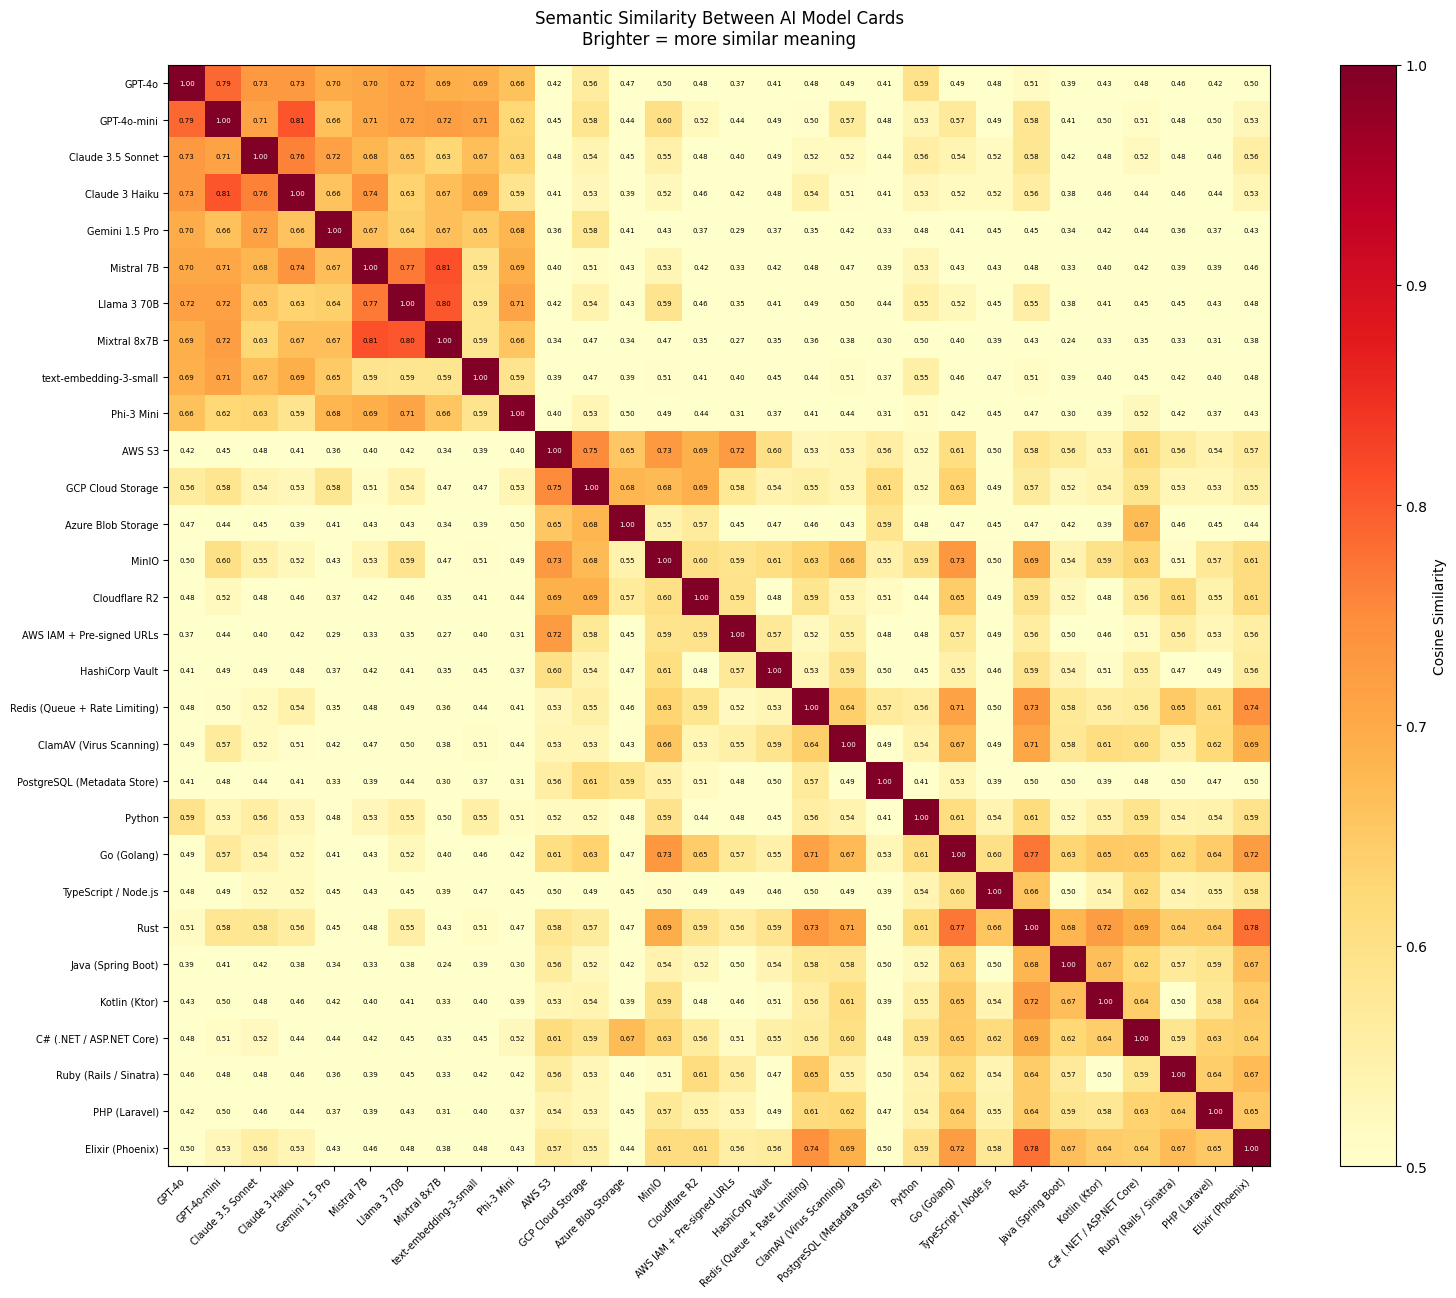


── Most semantically similar model pairs (excluding self) ──────

  0.810 ████████████████      Mistral 7B  ↔  Mixtral 8x7B
  0.806 ████████████████      GPT-4o-mini  ↔  Claude 3 Haiku
  0.805 ████████████████      Llama 3 70B  ↔  Mixtral 8x7B
  0.786 ███████████████       GPT-4o  ↔  GPT-4o-mini
  0.779 ███████████████       Rust  ↔  Elixir (Phoenix)
  0.773 ███████████████       Go (Golang)  ↔  Rust
  0.768 ███████████████       Mistral 7B  ↔  Llama 3 70B
  0.760 ███████████████       Claude 3.5 Sonnet  ↔  Claude 3 Haiku



💡  Notice: cloud storage options (S3, GCS, Azure Blob) cluster together. Programming languages cluster separately. LLMs form their own group. This is why retrieval works — similar meaning → similar vector → found together.

In [11]:
# ── Cosine similarity heatmap — one vector per model card ─────────────────────
section("Cosine Similarity Heatmap — all 30 model cards")

# Average chunk embeddings per card to get one vector per card
card_vectors = {}
for chunk in all_chunks:
    did = chunk["doc_id"]
    if did not in card_vectors:
        card_vectors[did] = []
    card_vectors[did].append(chunk["embedding"])

doc_ids  = [c["doc_id"] for c in MODEL_CARDS]
labels   = [c["model"]  for c in MODEL_CARDS]
card_embs = np.array([
    np.mean(card_vectors[did], axis=0) for did in doc_ids
])

# Normalise → cosine similarity = dot product
norms   = np.linalg.norm(card_embs, axis=1, keepdims=True)
normed  = card_embs / norms
sim_mat = normed @ normed.T

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 13))
im = ax.imshow(sim_mat, cmap="YlOrRd", vmin=0.5, vmax=1.0)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(labels, fontsize=7)

# Annotate cells
for i in range(len(labels)):
    for j in range(len(labels)):
        val = sim_mat[i, j]
        colour = "white" if val > 0.85 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=5, color=colour)

plt.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title("Semantic Similarity Between AI Model Cards\n"
             "Brighter = more similar meaning", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("week4_similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print top similar pairs ────────────────────────────────────────────────────
section("Most semantically similar model pairs (excluding self)")
pairs = []
for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        pairs.append((sim_mat[i,j], labels[i], labels[j]))
pairs.sort(reverse=True)
for score, a, b in pairs[:8]:
    bar = "█" * int(score * 20)
    print(f"  {score:.3f} {bar:<20}  {a}  ↔  {b}")

observe("Notice: cloud storage options (S3, GCS, Azure Blob) cluster together. "
        "Programming languages cluster separately. LLMs form their own group. "
        "This is why retrieval works — similar meaning → similar vector → found together.")

---
## Step 4 — Vector DB: Building the Chroma Index

We store all chunk embeddings in **Chroma** — an open-source vector database.  
Chroma persists the index locally and stores metadata (`doc_id`, `model`, `provider`) alongside each vector.

At query time, Chroma converts the query to an embedding and finds the nearest chunk vectors in milliseconds.

In [12]:
banner("Building Chroma Vector Index")

chroma_client = chromadb.PersistentClient(path="./chroma_week4")

# Drop and recreate for a clean demo run
try:
    chroma_client.delete_collection("model_cards")
except Exception:
    pass

collection = chroma_client.create_collection(
    name="model_cards",
    metadata={"hnsw:space": "cosine"}   # cosine similarity index
)

collection.add(
    ids        = [c["chunk_id"]  for c in all_chunks],
    embeddings = [c["embedding"].tolist() for c in all_chunks],
    documents  = [c["text"]      for c in all_chunks],
    metadatas  = [
        {"doc_id": c["doc_id"], "model": c["model"], "provider": c["provider"]}
        for c in all_chunks
    ]
)

success(f"Chroma index ready — {collection.count()} chunks indexed")
print(f"  Collection : model_cards")
print(f"  Distance   : cosine")
print(f"  Persist    : ./chroma_week4/")
print()

def embed_query(query: str) -> list:
    """Embed a single query string using OpenAI."""
    resp = oai.embeddings.create(model=EMBED_MODEL, input=[query])
    return resp.data[0].embedding

observe("The index is now a searchable map of meaning. "
        "Every chunk lives at a position in 1,536-dimensional space. "
        "A query lands near the chunks that share its meaning.")


══════════════════════════════════════════════════════════════════════
  Building Chroma Vector Index
══════════════════════════════════════════════════════════════════════



✅  Chroma index ready — 148 chunks indexed

  Collection : model_cards
  Distance   : cosine
  Persist    : ./chroma_week4/




💡  The index is now a searchable map of meaning. Every chunk lives at a position in 1,536-dimensional space. A query lands near the chunks that share its meaning.

---
## How Retrieval Works — Three Stages

Before we retrieve anything, here's what the three tools do and why we need all three.

---

### Stage A — Chroma (Semantic Search)

Chroma is a **vector database**. Every chunk is stored as a list of numbers — its **embedding**.  
When you query it, your question is also converted to numbers. Chroma finds the chunks whose numbers are *closest* to your question's numbers.

> **Engineering analogy:** It's a nearest-neighbour lookup in 1,536-dimensional space — like a `k-NN` query, but on meaning instead of coordinates.

**Strength:** Finds semantically similar content even if the exact words don't match.  
**Weakness:** Can miss chunks that contain the exact keyword you typed.

---

### Stage B — BM25 (Keyword Re-scoring)

BM25 is a classical **keyword ranking algorithm** — the same family that powered search engines before neural models.  
It scores each chunk based on how many query words appear in it, adjusted for how rare those words are across the whole corpus.

> **Engineering analogy:** A weighted `LIKE '%keyword%'` across all chunks — but smarter. Rare words score higher than common ones.

We combine BM25 with Chroma's score: **60% semantic + 40% keyword**. This hybrid catches exact term matches (e.g. `GPT-4o-mini`) that semantic search might miss.

**Strength:** Catches exact keyword matches Chroma might miss.  
**Weakness:** Doesn't understand meaning — `fast` and `high-performance` are different words to BM25.

---

### Stage C — Cross-Encoder Reranking

After Stages A and B we have 8 candidates. The cross-encoder reads **both the query and each chunk together** and scores how relevant they truly are to each other.  
This is a small transformer model (`ms-marco-MiniLM-L-6-v2`) fine-tuned specifically to judge query-document relevance.

> **Engineering analogy:** Stages A and B shortlist candidates quickly (cheap). The cross-encoder is the final reviewer who reads both documents carefully (accurate but slow).  
> You'd never run the cross-encoder over all chunks — only the top 8.

**Strength:** Deep, accurate relevance judgement — promotes the *truly* relevant chunk to rank 1.  
**Weakness:** Slow. Only feasible on a small candidate set, not the full corpus.

---

### Why Three Stages?

| Stage | Tool | What it optimises | Speed |
|-------|------|-------------------|-------|
| A | Chroma | Meaning / semantics | Fast (ANN index) |
| B | BM25 | Exact keywords | Fast (inverted index) |
| C | Cross-encoder | True relevance | Slow (transformer inference) |

Each stage filters and re-ranks the previous stage's output.  
By the time text reaches the LLM, it has passed three independent relevance filters.

```
Query
  → Stage A: Chroma semantic search     (top 10 by cosine similarity)
  → Stage B: BM25 hybrid re-score       (keyword overlap re-ranks)
  → Stage C: Cross-encoder rerank       (deep relevance model, top 5)
```

---
## Step 5 — Pure Retrieval Pipeline

Three stages — each one prints its results so you see the rankings **changing**.

No generation yet — **exact text from the model cards only**.

In [13]:
# ── Load cross-encoder (tiny, CPU-friendly) ───────────────────────────────────
section("Loading cross-encoder reranker...")
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
success("Cross-encoder ready (ms-marco-MiniLM-L-6-v2)")

# ── BM25 index over all chunks ────────────────────────────────────────────────
tokenised_corpus = [c["text"].lower().split() for c in all_chunks]
bm25 = BM25Okapi(tokenised_corpus)
success(f"BM25 index built over {len(all_chunks)} chunks")


── Loading cross-encoder reranker... ───────────────────────────

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]


✅  Cross-encoder ready (ms-marco-MiniLM-L-6-v2)


✅  BM25 index built over 148 chunks

In [14]:
# ── Improved Retrieval Pipeline v2 ───────────────────────────────────────────
def retrieve_pipeline(query: str, semantic_k: int = 12, final_k: int = 5, 
                        verbose: bool = True):
    """
    Enhanced 3-stage retrieval with better scoring and safety.
    """
    if verbose:
        banner(f"Retrieval Pipeline v2")
        print(f"  Query: {query}\n")
    
    # Stage A: Semantic Search
    q_emb = embed_query(query)
    results = collection.query(
        query_embeddings=[q_emb],
        n_results=semantic_k,
        include=["documents", "metadatas", "distances"]
    )
    
    if not results.get("ids") or not results["ids"][0]:
        warn("No relevant chunks found.")
        return []
    
    stage_a = []
    for i in range(len(results["ids"][0])):
        stage_a.append({
            "chunk_id": results["ids"][0][i],
            "doc_id": results["metadatas"][0][i]["doc_id"],
            "model": results["metadatas"][0][i]["model"],
            "provider": results["metadatas"][0][i]["provider"],
            "text": results["documents"][0][i],
            "cosine_sim": 1 - results["distances"][0][i],
        })
    
    if verbose:
        section(f"Stage A — Semantic Search (top {semantic_k})")
        for r in stage_a[:8]:
            bar = "█" * int(r['cosine_sim'] * 20)
            print(f"  [{r['doc_id']}] {r['model']:<25} sim={r['cosine_sim']:.3f} {bar}")
    
    # Stage B: Hybrid (improved normalization)
    tokenised_query = query.lower().split()
    bm25_scores = bm25.get_scores(tokenised_query)
    max_bm25 = bm25_scores.max() + 1e-8
    
    chunk_text_map = {c["text"]: idx for idx, c in enumerate(all_chunks)}
    
    for r in stage_a:
        idx = chunk_text_map.get(r["text"], -1)
        bm25_score = bm25_scores[idx] if idx >= 0 else 0.0
        r["bm25_score"] = bm25_score
        norm_bm25 = min(bm25_score / max_bm25, 1.0)
        r["hybrid_score"] = 0.65 * r["cosine_sim"] + 0.35 * norm_bm25
    
    stage_b = sorted(stage_a, key=lambda x: x["hybrid_score"], reverse=True)
    
    if verbose:
        section("Stage B — Hybrid Re-scoring")
        for r in stage_b[:6]:
            bar = "█" * int(r['hybrid_score'] * 20)
            print(f"  [{r['doc_id']}] {r['model']:<20} hybrid={r['hybrid_score']:.3f} {bar}")
    
    # Stage C: Cross-encoder reranking
    pairs = [(query, r["text"]) for r in stage_b]
    ce_scores = reranker.predict(pairs)
    
    for i, r in enumerate(stage_b):
        r["rerank_score"] = float(ce_scores[i])
    
    final_chunks = sorted(stage_b, key=lambda x: x["rerank_score"], reverse=True)[:final_k]
    
    if verbose:
        section(f"Stage C — Final Top {final_k} Chunks")
        unique_docs = len(set(c["doc_id"] for c in final_chunks))
        success(f"Retrieved from {unique_docs} unique document(s)")
        for rank, r in enumerate(final_chunks, 1):
            print(f"  {rank}. [{r['doc_id']}] {r['model']} — score: {r['rerank_score']:.4f}")
    
    return final_chunks

In [15]:
# ── Demo Query 1 ──────────────────────────────────────────────────────────────
results_q1 = retrieve_pipeline(
    "Which model is best for summarising long documents?"
)


══════════════════════════════════════════════════════════════════════
  Retrieval Pipeline v2
══════════════════════════════════════════════════════════════════════
  Query: Which model is best for summarising long documents?




── Stage A — Semantic Search (top 12) ──────────────────────────

  [LM-004] Claude 3 Haiku            sim=0.571 ███████████
  [LM-004] Claude 3 Haiku            sim=0.527 ██████████
  [LM-005] Gemini 1.5 Pro            sim=0.516 ██████████
  [LM-003] Claude 3.5 Sonnet         sim=0.508 ██████████
  [LM-006] Mistral 7B                sim=0.504 ██████████
  [LM-004] Claude 3 Haiku            sim=0.502 ██████████
  [LM-005] Gemini 1.5 Pro            sim=0.492 █████████
  [LM-008] Mixtral 8x7B              sim=0.492 █████████



── Stage B — Hybrid Re-scoring ─────────────────────────────────

  [LM-003] Claude 3.5 Sonnet    hybrid=0.573 ███████████
  [LM-005] Gemini 1.5 Pro       hybrid=0.504 ██████████
  [LM-005] Gemini 1.5 Pro       hybrid=0.502 ██████████
  [LM-004] Claude 3 Haiku       hybrid=0.490 █████████
  [LM-004] Claude 3 Haiku       hybrid=0.478 █████████
  [LM-002] GPT-4o-mini          hybrid=0.458 █████████



── Stage C — Final Top 5 Chunks ────────────────────────────────


✅  Retrieved from 3 unique document(s)

  1. [LM-005] Gemini 1.5 Pro — score: 5.9618
  2. [LM-005] Gemini 1.5 Pro — score: 5.4244
  3. [LM-003] Claude 3.5 Sonnet — score: 4.2921
  4. [LM-003] Claude 3.5 Sonnet — score: 3.7736
  5. [LM-004] Claude 3 Haiku — score: 3.6889


In [16]:
# ── Demo Query 2 ──────────────────────────────────────────────────────────────
results_q2 = retrieve_pipeline(
    "What are my open source LLM options?"
)


══════════════════════════════════════════════════════════════════════
  Retrieval Pipeline v2
══════════════════════════════════════════════════════════════════════
  Query: What are my open source LLM options?




── Stage A — Semantic Search (top 12) ──────────────────────────

  [BC-007] HashiCorp Vault           sim=0.429 ████████
  [PL-007] C# (.NET / ASP.NET Core)  sim=0.421 ████████
  [PL-009] PHP (Laravel)             sim=0.421 ████████
  [BC-008] Redis (Queue + Rate Limiting) sim=0.413 ████████
  [BC-004] MinIO                     sim=0.399 ███████
  [BC-009] ClamAV (Virus Scanning)   sim=0.397 ███████
  [PL-004] Rust                      sim=0.393 ███████
  [PL-006] Kotlin (Ktor)             sim=0.376 ███████



── Stage B — Hybrid Re-scoring ─────────────────────────────────

  [BC-007] HashiCorp Vault      hybrid=0.279 █████
  [PL-007] C# (.NET / ASP.NET Core) hybrid=0.273 █████
  [PL-009] PHP (Laravel)        hybrid=0.273 █████
  [BC-008] Redis (Queue + Rate Limiting) hybrid=0.268 █████
  [BC-004] MinIO                hybrid=0.259 █████
  [BC-009] ClamAV (Virus Scanning) hybrid=0.258 █████



── Stage C — Final Top 5 Chunks ────────────────────────────────


✅  Retrieved from 5 unique document(s)

  1. [LM-007] Llama 3 70B — score: -0.8380
  2. [PL-001] Python — score: -1.4764
  3. [BC-009] ClamAV (Virus Scanning) — score: -1.7594
  4. [BC-004] MinIO — score: -1.8117
  5. [BC-007] HashiCorp Vault — score: -2.1518


In [17]:
# ── Demo Query 3 ──────────────────────────────────────────────────────────────
results_q3 = retrieve_pipeline(
    "I need to find best programming language for LLM development"
)


══════════════════════════════════════════════════════════════════════
  Retrieval Pipeline v2
══════════════════════════════════════════════════════════════════════
  Query: I need to find best programming language for LLM development




── Stage A — Semantic Search (top 12) ──────────────────────────

  [PL-001] Python                    sim=0.458 █████████
  [PL-003] TypeScript / Node.js      sim=0.358 ███████
  [PL-001] Python                    sim=0.338 ██████
  [LM-007] Llama 3 70B               sim=0.336 ██████
  [PL-003] TypeScript / Node.js      sim=0.336 ██████
  [LM-006] Mistral 7B                sim=0.334 ██████
  [PL-001] Python                    sim=0.333 ██████
  [PL-007] C# (.NET / ASP.NET Core)  sim=0.323 ██████



── Stage B — Hybrid Re-scoring ─────────────────────────────────

  [LM-006] Mistral 7B           hybrid=0.479 █████████
  [PL-001] Python               hybrid=0.470 █████████
  [PL-001] Python               hybrid=0.430 ████████
  [LM-007] Llama 3 70B          hybrid=0.382 ███████
  [PL-003] TypeScript / Node.js hybrid=0.355 ███████
  [PL-005] Java (Spring Boot)   hybrid=0.320 ██████



── Stage C — Final Top 5 Chunks ────────────────────────────────


✅  Retrieved from 3 unique document(s)

  1. [PL-001] Python — score: 4.3661
  2. [PL-001] Python — score: 3.1379
  3. [PL-003] TypeScript / Node.js — score: 1.1165
  4. [PL-003] TypeScript / Node.js — score: -1.6025
  5. [LM-006] Mistral 7B — score: -8.3780


---
## Step 6 — Full RAG: Retrieval + Generation

Now we combine the pipeline:

1. **Retrieve** the top 5 chunks (Stage C above)
2. **Show the exact prompt** we're sending to GPT-4o-mini
3. **Compare** the cold answer (from Cell 0) vs the grounded RAG answer

This is the payoff moment.

In [18]:
def rag_answer_v2(query: str, verbose_retrieval: bool = True):
    """Improved full RAG pipeline."""
    chunks = retrieve_pipeline(query, verbose=verbose_retrieval)  # using v2 pipeline
    
    if not chunks:
        return ("I don't have sufficient information in my knowledge base "
                "to answer this question accurately."), [], "", ""
    
    context_block = "\n\n".join([
        f"[SOURCE {i+1} | {c['doc_id']} | {c['model']} | {c['provider']}]\n{c['text']}"
        for i, c in enumerate(chunks)
    ])
    
    system = (
        "You are a precise backend architecture advisor. Answer using ONLY the "
        "provided source documents. Rules:\n"
        "1. Cite sources with [DOC-ID] (e.g. [BC-001]).\n"
        "2. Use information from all relevant sources.\n"
        "3. If the context doesn't contain enough information, say so clearly.\n"
        "4. Be practical and structured."
    )
    
    user = f"Context Documents:\n\n{context_block}\n\nQuestion: {query}"
    
    answer = chat(system=system, user=user, temperature=0.0)
    
    return answer, chunks, system, user

In [19]:
# ── Step 6 — Full RAG: Retrieval + Generation (Final) ───────────────────────
banner("Full RAG — The Payoff")

query = DEMO_QUERY

# Step 1: Retrieve + Generate
section("Step 1 of 3 — Retrieving relevant chunks")
grounded_answer, chunks, system_msg, user_msg = rag_answer_v2(
    query, 
    verbose_retrieval=True
)

print(f"Retrieved {len(chunks)} chunks from: "
      f"{', '.join([f'{c['doc_id']} ({c['model']})' for c in chunks])}")

# Step 2: Show Prompt
section("Step 2 of 3 — Exact prompt sent to GPT-4o-mini")
print("SYSTEM:")
for line in system_msg.splitlines():
    print(f"  {line}")
print("\nUSER (first 900 chars):")
print(user_msg[:900] + "\n...")

observe("The LLM only sees the retrieved context + strict instructions → grounded output.")

# Step 3: Comparison
section("Step 3 of 3 — Cold vs RAG Answer")
compare(
    "❌ COLD LLM (no context)",
    cold_answer,
    "✅ RAG (grounded in your corpus)",
    grounded_answer
)

discuss(
    "The RAG version is specific, cites sources, and pulls from multiple domains. "
    "This is exactly why RAG exists."
)


══════════════════════════════════════════════════════════════════════
  Full RAG — The Payoff
══════════════════════════════════════════════════════════════════════



── Step 1 of 3 — Retrieving relevant chunks ────────────────────


══════════════════════════════════════════════════════════════════════
  Retrieval Pipeline v2
══════════════════════════════════════════════════════════════════════
  Query: I need to build a high-performance backend API that can process large files and store them securely in cloud object storage. What are my options?




── Stage A — Semantic Search (top 12) ──────────────────────────

  [BC-001] AWS S3                    sim=0.609 ████████████
  [BC-001] AWS S3                    sim=0.593 ███████████
  [BC-002] GCP Cloud Storage         sim=0.584 ███████████
  [BC-005] Cloudflare R2             sim=0.577 ███████████
  [BC-001] AWS S3                    sim=0.569 ███████████
  [PL-002] Go (Golang)               sim=0.564 ███████████
  [PL-008] Ruby (Rails / Sinatra)    sim=0.561 ███████████
  [BC-001] AWS S3                    sim=0.559 ███████████


...

SYSTEM:
  You are a precise backend architecture advisor. Answer using ONLY the provided source documents. Rules:
  1. Cite sources with [DOC-ID] (e.g. [BC-001]).
  2. Use information from all relevant sources.
  3. If the context doesn't contain enough information, say so clearly.
  4. Be practical and structured.

USER (first 900 chars):
Context Documents:

[SOURCE 1 | BC-001 | AWS S3 | Amazon Web Services]
Best use cases: primary object store for AWS-based architectures, media storage, backup, data lake landing zones, and storing files processed by a backend API.

[SOURCE 2 | PL-002 | Go (Golang) | Google / Open Source]
Best use cases: high-throughput file upload APIs, cloud-native microservices, and latency-critical backend services. Open-source under BSD licence.

[SOURCE 3 | PL-008 | Ruby (Rails / Sinatra) | Matz / Open Source]
Active Storage (built into Rails) provides a unified API for attaching files and uploading them to AWS S3, GCP Cloud Storage, or Azure Blob Storage with m


💡  The LLM only sees the retrieved context + strict instructions → grounded output.


── Step 3 of 3 — Cold vs RAG Answer ────────────────────────────


────────────────────────────────────────────────────────────────────────────────
  ❌ COLD LLM (no context)
────────────────────────────────────────────────────────────────────────────────
    To build a high-performance backend API for processing large files and
    securely storing them in cloud object storage, consider the following
    options:  1. **Cloud Providers**:    - **AWS S3**: Use AWS Lambda for
    processing and S3 for storage. Implement event-driven architecture with S3
    triggers.    - **Google Cloud Storage**: Utilize Google Cloud Functions for
    processing and Cloud Storage for secure file storage.    - **Azure Blob
    Storage**: Use Azure Functions for processing files and Blob Storage for
    storage.  2. **API Frameworks**:    - **Node.js**: Use Express or Fastify
    for creating the API, and leverage streams for handling large file uploads.
    - **Python**: Use Flask or FastAPI for the API, and libraries like `boto3`
    or `google-cloud-storage` for cloud


🗣️   The RAG version is specific, cites sources, and pulls from multiple domains. This is exactly why RAG exists.

In [20]:
# ── Multiple Queries Demo ─────────────────────────────────────────────────────
banner("MULTIPLE QUERIES DEMO — Different Retrieval Behaviors")

test_queries = [
    {
        "name": "Main Query",
        "query": DEMO_QUERY,
        "desc": "Cross-domain (Languages + Storage)"
    },
    {
        "name": "Long Context",
        "query": "Which model is best for summarizing very long documents or codebases?",
        "desc": "Long-context LLMs"
    },
    {
        "name": "Self-hosted",
        "query": "What are my open-source self-hostable options?",
        "desc": "Privacy / on-prem focus"
    },
    {
        "name": "Cost Sensitive",
        "query": "What are the most cost-effective options for high-volume file processing?",
        "desc": "Pricing & efficiency"
    },
    {
        "name": "Out-of-Scope",
        "query": "How do I implement real-time video streaming with WebRTC?",
        "desc": "Should return limited info"
    }
]

results_summary = []

for item in test_queries:
    section(f"Query: {item['name']}")
    print(f"→ {item['desc']}")
    
    answer, chunks, _, _ = rag_answer_v2(item["query"], verbose_retrieval=False)
    
    summary = {
        "Query": item["name"],
        "Chunks": len(chunks),
        "Unique Docs": len(set(c["doc_id"] for c in chunks)) if chunks else 0,
        "Answer Length": len(answer)
    }
    results_summary.append(summary)
    
    display(Markdown(f"**Answer:**\n{answer}"))
    print("─" * 80)

# Summary Table
section("Summary Across All Queries")
summary_df = pd.DataFrame(results_summary)
display(summary_df)

observe("Notice how different queries retrieve different numbers of chunks and domains.")


══════════════════════════════════════════════════════════════════════
  MULTIPLE QUERIES DEMO — Different Retrieval Behaviors
══════════════════════════════════════════════════════════════════════



── Query: Main Query ───────────────────────────────────────────

→ Cross-domain (Languages + Storage)


**Answer:**
To build a high-performance backend API that can process large files and store them securely in cloud object storage, you have several options based on the provided sources:

1. **Programming Language**:
   - **Go (Golang)**: This language is well-suited for high-throughput file upload APIs and cloud-native microservices. It is designed for performance and can handle latency-critical backend services effectively [PL-002].

2. **Cloud Object Storage Options**:
   - **AWS S3**: This is a primary object store for AWS-based architectures, ideal for media storage, backups, and as a data lake landing zone. It is suitable for storing files processed by your backend API [BC-001].
   - **GCP Cloud Storage**: This is optimal for GCP-native architectures and is particularly useful for ML training data and media pipelines. It offers various storage classes (Standard, Nearline, Coldline, Archive) for cost optimization based on access frequency. It also provides encryption at rest and integrates well with other GCP services [BC-002][BC-005].

3. **File Processing**:
   - If you choose Ruby, you can utilize Active Storage for a unified API to attach and upload files to cloud storage. However, Ruby is less suited for CPU-bound tasks like large file processing. For heavy tasks, you would need to delegate to FFmpeg subprocesses or a dedicated worker service [PL-008].
   - For Go, you can implement efficient file processing directly within your API, leveraging its performance capabilities.

4. **Security**:
   - Both AWS S3 and GCP Cloud Storage provide secure storage options. GCP offers encryption at rest by default and allows for customer-managed encryption keys (CMEK) for stricter compliance [BC-005].

In summary, for a high-performance backend API that processes large files, consider using Go for development and choose between AWS S3 or GCP Cloud Storage for secure file storage, depending on your cloud architecture preference.

────────────────────────────────────────────────────────────────────────────────


...

**Answer:**
The provided context documents do not contain specific information on implementing real-time video streaming with WebRTC. Therefore, I cannot provide a structured answer based on the available sources.

────────────────────────────────────────────────────────────────────────────────



── Summary Across All Queries ──────────────────────────────────

,Query,Chunks,Unique Docs,Answer Length
0,Main Query,5,4,1945
1,Long Context,5,2,713
2,Self-hosted,5,5,758
3,Cost Sensitive,5,4,1508
4,Out-of-Scope,5,4,201



💡  Notice how different queries retrieve different numbers of chunks and domains.

---
## Step 7 — Why Different Techniques? The Full Picture

Today you saw three of these four in action. The fourth arrives in Week 5 (Neo4j).

In [ ]:
banner("RAG Technique Comparison")

comparison = pd.DataFrame([
    {
        "Technique":      "Basic Semantic Search",
        "How it works":   "Embed query → find nearest vectors in Chroma",
        "Best for":       "General meaning-based retrieval",
        "Weakness":       "Misses exact keyword matches (e.g. 'GPT-4o-mini')",
        "Seen today":     "✅ Stage A"
    },
    {
        "Technique":      "Hybrid (Vector + BM25)",
        "How it works":   "Combine cosine similarity score with BM25 keyword score",
        "Best for":       "Queries mixing meaning AND exact terms",
        "Weakness":       "Tuning the blend ratio (60/40 here) requires experimentation",
        "Seen today":     "✅ Stage B"
    },
    {
        "Technique":      "Cross-Encoder Reranking",
        "How it works":   "Deep model scores (query, chunk) pairs for true relevance",
        "Best for":       "Promoting the *most* relevant chunk to rank 1",
        "Weakness":       "Slower — only feasible on top-N candidates, not full corpus",
        "Seen today":     "✅ Stage C"
    },
    {
        "Technique":      "Multi-Query",
        "How it works":   "LLM generates 3–5 query variants → retrieve for each → merge",
        "Best for":       "Ambiguous questions with multiple valid phrasings",
        "Weakness":       "Extra LLM calls per query — higher latency and cost",
        "Seen today":     "⏭️  Week 5"
    },
    {
        "Technique":      "Graph RAG (Neo4j)",
        "How it works":   "Traverse knowledge graph relationships instead of vector search",
        "Best for":       "Structured relationships: 'which models support X AND Y'",
        "Weakness":       "Requires upfront schema and graph construction",
        "Seen today":     "⏭️  Week 5"
    },
])

pd.set_option("display.max_colwidth", 60)
display(comparison)

observe(
    "Today covered the first 3 techniques — semantic, hybrid, and reranking — "
    "on a real corpus with real OpenAI embeddings. "
    "Week 5: 30 mins on Neo4j graph RAG for relationship-based retrieval."
)

---
## Session Summary

| Concept | What you saw |
|---------|-------------|
| **Why RAG** | Cold LLM gave generic advice; RAG answered from your specific corpus |
| **Corpus** | 30 cards across LLMs, Cloud/Infra, and Programming Languages |
| **Chunking** | 300-char chunks, 50-char overlap — pandas table |
| **Embeddings** | OpenAI `text-embedding-3-small`, 1,536 dims, cosine heatmap |
| **Vector DB** | Chroma, cosine distance, persistent index |
| **Hybrid retrieval** | Chroma (semantic) + BM25 (keyword) combined |
| **Reranking** | Cross-encoder promoted the truly relevant chunk to rank 1 |
| **Generation** | GPT-4o-mini answered from ALL retrieved context, cited doc IDs |

**The multi-domain corpus is the key lesson:** a real architecture decision about  
*"which LLM + which storage + which language"* requires retrieval across all three domains.  
RAG spans them naturally — a keyword search or hard-coded if/else cannot.

**Next: Week 5 — Neo4j Graph RAG (30 min)**  
When the question is *"which options are open-source AND support large files AND have Python SDKs?"*,  
vector search struggles with AND-conditions. Graph traversal answers it directly.
